<a href="https://colab.research.google.com/github/ibrahimgulcan/insider-threat-analyzer/blob/main/aiprojem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install imbalanced-learn
from google.colab import drive
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/UEBA_Proje_Data/'
LDAP_PATH = os.path.join(BASE_PATH, 'LDAP')
ANSWERS_PATH = os.path.join(BASE_PATH, 'answers')

print("\n🚀 SİSTEM BAŞLATILIYOR...")


tum_kullanicilar = set()
if os.path.exists(LDAP_PATH):
    for dosya in sorted([f for f in os.listdir(LDAP_PATH) if f.endswith('.csv')]):
        df_aylik = pd.read_csv(os.path.join(LDAP_PATH, dosya))
        df_aylik.columns = [str(c).strip().lower() for c in df_aylik.columns]
        user_col = next((c for c in ['user', 'employee', 'user_id'] if c in df_aylik.columns), 'user')
        tum_kullanicilar.update(df_aylik[user_col].dropna().unique())

df_master = pd.DataFrame(list(tum_kullanicilar), columns=['user'])

gercek_hackerlar = set()
user_pattern = re.compile(r'[A-Z]{3}\d{4}')
if os.path.exists(ANSWERS_PATH):
    for root, dirs, files in os.walk(ANSWERS_PATH):
        for f in files:
            if f.endswith('.csv'):
                gercek_hackerlar.update(user_pattern.findall(f))
                try:
                    with open(os.path.join(root, f), 'r', encoding='utf-8', errors='ignore') as file:
                        for line in file: gercek_hackerlar.update(user_pattern.findall(line))
                except: pass

clean_hacker_list = set(str(h).strip().lower() for h in gercek_hackerlar)
df_master['gercek_hacker'] = df_master['user'].astype(str).str.strip().str.lower().apply(lambda x: 1 if x in clean_hacker_list else 0)

print(f"✅ Toplam {len(df_master)} çalışan profili başarıyla oluşturuldu!")

Mounted at /content/drive

🚀 SİSTEM BAŞLATILIYOR...
✅ Toplam 1000 çalışan profili başarıyla oluşturuldu!


In [ ]:


def akilli_log_taramasi(file_name, analiz_tipi):
    file_path = os.path.join(BASE_PATH, file_name)
    if not os.path.exists(file_path): return pd.DataFrame()
    riskli_paketler = []
    for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False):
        chunk.columns = [str(c).strip().lower() for c in chunk.columns]
        user_col = next((c for c in ['user', 'employee', 'user_id'] if c in chunk.columns), None)
        if user_col and not df_master.empty: chunk = chunk[chunk[user_col].isin(df_master['user'])]
        if chunk.empty: continue

        if analiz_tipi == 'gece' and 'date' in chunk.columns:
            chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')
            riskli = chunk[(chunk['date'].dt.hour >= 18) | (chunk['date'].dt.hour <= 8)]
        elif analiz_tipi == 'http':
            riskli = chunk[chunk['url'].astype(str).str.lower().str.contains('upload|drive|cloud|dropbox|mega', na=False)] if 'url' in chunk.columns else chunk
        elif analiz_tipi == 'email_disari':
            if 'to' in chunk.columns and 'attachments' in chunk.columns:
                chunk['attachments'] = pd.to_numeric(chunk['attachments'], errors='coerce').fillna(0)
                dis_mail = chunk[chunk['to'].astype(str).str.lower().str.contains('gmail|yahoo|hotmail|outlook|proton', na=False)]
                riskli = dis_mail[dis_mail['attachments'] > 0]
        elif analiz_tipi == 'email_nlp':
            tehdit_kelimeleri = 'confidential|secret|salary|resume|cv|password|hidden|ssn|resign'
            riskli_icerik = pd.Series(False, index=chunk.index)
            if 'content' in chunk.columns: riskli_icerik = riskli_icerik | chunk['content'].astype(str).str.lower().str.contains(tehdit_kelimeleri, na=False)
            if 'subject' in chunk.columns: riskli_icerik = riskli_icerik | chunk['subject'].astype(str).str.lower().str.contains(tehdit_kelimeleri, na=False)
            riskli = chunk[riskli_icerik]
        elif analiz_tipi == 'file_burst':
            riskli = chunk[chunk['filename'].astype(str).str.lower().str.contains('.zip|.rar|.exe', na=False)] if 'filename' in chunk.columns else chunk

        if 'riskli' in locals() and not riskli.empty: riskli_paketler.append(riskli)
    return pd.concat(riskli_paketler, ignore_index=True) if riskli_paketler else pd.DataFrame()

df_logon = akilli_log_taramasi('logon.csv', 'gece')
df_device = akilli_log_taramasi('device.csv', 'gece')
df_http = akilli_log_taramasi('http.csv', 'http')
df_email_disari = akilli_log_taramasi('email.csv', 'email_disari')
df_email_nlp = akilli_log_taramasi('email.csv', 'email_nlp')
df_file_burst = akilli_log_taramasi('file.csv', 'file_burst')

def sayilari_cikar(df, col_name): return df.groupby('user').size().reset_index(name=col_name) if not df.empty else pd.DataFrame(columns=['user', col_name])
for df_temp, col in zip([df_logon, df_device, df_http, df_email_disari, df_email_nlp, df_file_burst],
                        ['gece_logon', 'gece_usb', 'bulut_upload', 'disari_sizdirma', 'nlp_tehdit', 'panik_dosya']):
    df_master = df_master.merge(sayilari_cikar(df_temp, col), on='user', how='left').fillna(0)

psycho_path = os.path.join(BASE_PATH, 'psychometric.csv')
if os.path.exists(psycho_path):
    df_psycho = pd.read_csv(psycho_path)
    df_psycho.columns = [str(c).strip().lower() for c in df_psycho.columns]
    user_col = next((c for c in ['user', 'employee_name', 'user_id'] if c in df_psycho.columns), 'user')
    df_psycho_scores = df_psycho[[user_col, 'a', 'n']].rename(columns={user_col: 'user', 'a': 'uyumluluk', 'n': 'stres_seviyesi'})
    df_master = df_master.merge(df_psycho_scores, on='user', how='left').fillna(0)
else:
    df_master['uyumluluk'], df_master['stres_seviyesi'] = 0, 0

print("Matris hazır.")

Matris hazır.


 1. VERİ SETİNİN ANATOMİSİ VE EKSİK VERİ KONTROLÜ
Sütun Veri Tipleri:
user                object
gercek_hacker        int64
gece_logon           int64
gece_usb           float64
bulut_upload       float64
disari_sizdirma    float64
nlp_tehdit         float64
panik_dosya        float64
uyumluluk          float64
stres_seviyesi     float64
dtype: object

Eksik Veri Sayıları (Temizlik Öncesi):
Harika! Hiç eksik veri (NaN) yok.


 2. İSTATİSTİKSEL DERİNLİK (DESCRIBE)


,count,mean,std,min,max
gercek_hacker,1000.0,0.072,0.258617,0.0,1.0
gece_logon,1000.0,485.650,336.050472,20.0,2598.0
gece_usb,1000.0,66.061,251.204022,0.0,2540.0
bulut_upload,1000.0,175.639,444.547409,0.0,3809.0
disari_sizdirma,1000.0,84.561,110.682595,0.0,976.0
nlp_tehdit,1000.0,158.131,126.368987,0.0,882.0
panik_dosya,1000.0,25.967,83.790481,0.0,668.0
uyumluluk,1000.0,0.000,0.000000,0.0,0.0
stres_seviyesi,1000.0,0.000,0.000000,0.0,0.0



 3. SINIF DENGESİZLİĞİ VE KORELASYON GRAFİKLERİ


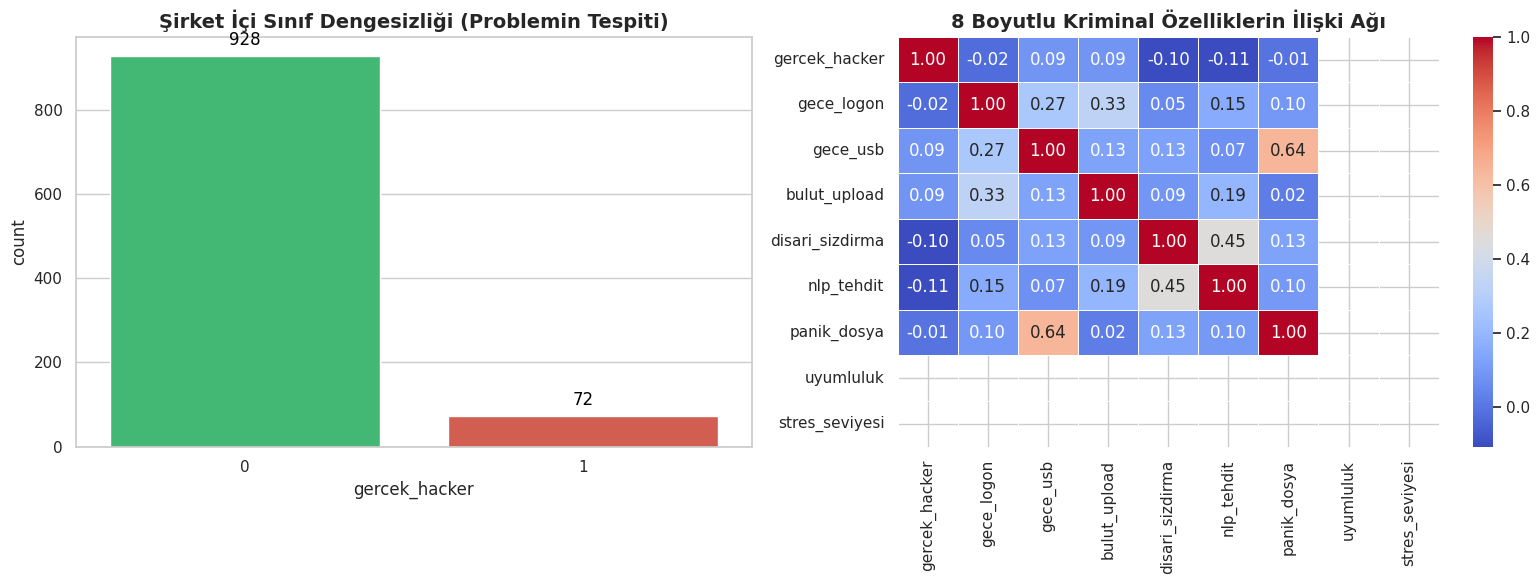

In [ ]:
print(" 1. VERİ SETİNİN ANATOMİSİ VE EKSİK VERİ KONTROLÜ")
print("="*50)
print(f"Sütun Veri Tipleri:\n{df_master.dtypes}\n")

eksik_veriler = df_master.isna().sum()
print("Eksik Veri Sayıları (Temizlik Öncesi):")
print(eksik_veriler[eksik_veriler > 0] if eksik_veriler.sum() > 0 else "Harika! Hiç eksik veri (NaN) yok.\n")
df_master = df_master.fillna(0) # Güvenlik katmanı

print("\n 2. İSTATİSTİKSEL DERİNLİK (DESCRIBE)")
print("="*50)
istatistik = df_master.describe().T
display(istatistik[['count', 'mean', 'std', 'min', 'max']])

print("\n 3. SINIF DENGESİZLİĞİ VE KORELASYON GRAFİKLERİ")
print("="*50)

# Grafik 1: Dengesizlik
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_master, x='gercek_hacker', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Şirket İçi Sınıf Dengesizliği (Problemin Tespiti)', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

# Grafik 2: Korelasyon
sayisal_veriler = df_master.drop(columns=['user'])
sns.heatmap(sayisal_veriler.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[1])
axes[1].set_title('8 Boyutlu Kriminal Özelliklerin İlişki Ağı', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Verileri makine öğrenmesi için Numpy dizilerine aktarma
X_raw = df_master[['gece_logon', 'gece_usb', 'bulut_upload', 'disari_sizdirma', 'nlp_tehdit', 'panik_dosya', 'uyumluluk', 'stres_seviyesi']].values
y_raw = df_master['gercek_hacker'].values

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print(" ADIM 3: Veriler Ölçeklendiriliyor ve SMOTE Uygulanıyor...")

# Hilesiz Train-Test Split (%80 Eğitim, %20 Saha Testi)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# SMOTE SADECE Eğitim verisine uygulanır
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_raw_scaled = scaler.transform(X_raw) # Tüm şirket saha testi için

# LSTM için 3D Matris Dönüşümü (Samples, TimeStep=1, Features=8)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_raw_lstm = X_raw_scaled.reshape(X_raw_scaled.shape[0], 1, X_raw_scaled.shape[1])



 ADIM 3: Veriler Ölçeklendiriliyor ve SMOTE Uygulanıyor...


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

print("🚀 ADIM 4: LSTM Ağımız Eğitiliyor")

model = Sequential([
    LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), activation='tanh', return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy')

# Eğitim Başlıyor
model.fit(X_train_lstm, y_train_smote, epochs=40, batch_size=32, verbose=0)

print("Eğitim Tamamlandı!")


🚀 ADIM 4: LSTM Ağımız Eğitiliyor
Eğitim Tamamlandı!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(" ADIM 5: F1 Skorunu zirveye çıkaracak 'Altın Şüphe Eşiği' bulunuyor...\n")

y_pred_probs_all = model.predict(X_raw_lstm, verbose=0).flatten()

en_iyi_f1 = 0
en_iyi_esik = 0.50

# 0.20 ile 0.95 arasındaki tüm ihtimalleri dene
for esik in np.arange(0.20, 0.95, 0.05):
    gecici_tahmin = (y_pred_probs_all >= esik).astype(int)
    gecici_f1 = f1_score(y_raw, gecici_tahmin)
    if gecici_f1 > en_iyi_f1:
        en_iyi_f1 = gecici_f1
        en_iyi_esik = esik

print(f"🎯 ALTIN EŞİK BULUNDU: %{int(en_iyi_esik*100)}")

y_pred_opt = (y_pred_probs_all >= en_iyi_esik).astype(int)
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_raw, y_pred_opt).ravel()

print("\n" + "="*60)
print(f" SMOTE + LSTM SAHA DAĞITIMI (Eşik: %{int(en_iyi_esik*100)})")
print("="*60)
print(f" YAKALANAN TOPLAM HACKER : {tp_opt} / {tp_opt + fn_opt}")
print(f" Yanlış Alarm (FP)       : {fp_opt}")
print(f" Temize Çıkan Masum     : {tn_opt}")
print("-" * 60)
print(" F1 ve PRECISION:")
labels_opt = ['Masum', 'Hacker'] if (tp_opt + fn_opt) > 0 else ['Masum']
print(classification_report(y_raw, y_pred_opt, target_names=labels_opt, digits=4))
print("="*60)

import joblib

model.save('/content/drive/MyDrive/UEBA_Proje_Data/lstm_ueba_champion.h5')
joblib.dump(scaler, '/content/drive/MyDrive/UEBA_Proje_Data/ueba_scaler.pkl')
print("Model ve Scaler başarıyla Drive'a kaydedildi!")

 ADIM 5: F1 Skorunu zirveye çıkaracak 'Altın Şüphe Eşiği' bulunuyor...



🎯 ALTIN EŞİK BULUNDU: %84

 SMOTE + LSTM SAHA DAĞITIMI (Eşik: %84)
 YAKALANAN TOPLAM HACKER : 65 / 72
 Yanlış Alarm (FP)       : 16
 Temize Çıkan Masum     : 912
------------------------------------------------------------
 F1 ve PRECISION:
              precision    recall  f1-score   support

       Masum     0.9924    0.9828    0.9875       928
      Hacker     0.8025    0.9028    0.8497        72

    accuracy                         0.9770      1000
   macro avg     0.8974    0.9428    0.9186      1000
weighted avg     0.9787    0.9770    0.9776      1000

Model ve Scaler başarıyla Drive'a kaydedildi!


In [ ]:
from google.colab import files
import joblib

print("Dosyalar hazırlanıyor...")

# 1. Modeli ve Scaler'ı Colab'ın geçici hafızasına kaydediyoruz
model.save('lstm_ueba_champion.h5')
joblib.dump(scaler, 'ueba_scaler.pkl')

print("Bilgisayarınıza indirme işlemi başlatılıyor.")


files.download('lstm_ueba_champion.h5')
files.download('ueba_scaler.pkl')

Dosyalar hazırlanıyor...
Bilgisayarınıza indirme işlemi başlatılıyor.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

print("Tüm şirket personeli LSTM Yapay Zekası tarafından analiz ediliyor...")

# 1. Eğittiğimiz LSTM modeli ile herkesin risk yüzdesini hesaplıyoruz
y_pred_probs_all = model.predict(X_raw_lstm, verbose=0).flatten()


df_export = pd.DataFrame()
df_export['user'] = df_master['user']

df_export['employee_name'] = df_master['user'].apply(lambda x: f"Personel_{x}")
df_export['department'] = "Bilişim / Finans"


df_export['usb_count'] = df_master['gece_usb']
df_export['gece_email'] = df_master['disari_sizdirma']
df_export['night_activity'] = df_master['gece_logon']
df_export['gece_dosya_islemi'] = df_master['panik_dosya']


df_export['ultimate_risk_skoru'] = np.round(y_pred_probs_all * 100, 2)

# 3. CSV dosyasını oluştur ve bilgisayara indir
df_export.to_csv('final_risk_table.csv', index=False)
files.download('final_risk_table.csv')

print("'final_risk_table.csv' başarıyla indirildi!")

Tüm şirket personeli LSTM Yapay Zekası tarafından analiz ediliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'final_risk_table.csv' başarıyla indirildi!
